# AC209B MS4

**AC209B Project — Group 14**

Team members:
- Ji Zhang (jizhang@g.harvard.edu)
- Mengchu Yue (mengchuyue@fas.harvard.edu)
- Xiaoyu Yang (xiaoyu_yang1@g.harvard.edu)

---

## Project summary

We replace OneRec's separately-trained Reward Model with **direct user behavior signals** (longview / like / follow / forward) as the supervision source for offline preference alignment. Seven training recipes were ablated; the simplest single-objective arm — **plain SFT on the chosen branch** — is the headline winner.

The most theoretically interesting finding is that **ORPO ties with SFT within noise** despite a fundamentally different objective. We trace this to a structural property of the task: when chosen and rejected items share a narrow categorical output space (codebook K = 8,192 — much smaller than typical LLM vocabularies of 50k–150k — and the same user context), SFT's implicit zero-sum redistribution already drains rejected — leaving the contrastive objective with nothing to add. Section 8 develops this argument.

## How to read this notebook

- **Default mode (cache-first)** — `RUN_INFERENCE_DEMO = False`, `RUN_TRAINING = False`. Everything in this notebook executes on a CPU in ~3 minutes; final results load from cached eval JSONs.
- **All training and evaluation code is visible** — both as inline functions on toy tensors (Sections 3, 5) and as imports from [`train/`](../train/) modules.
- **Reproducing the headline numbers from scratch** requires an 80GB GPU and ~17–38 hours per arm — see Section 4 for the launchers.

## Section map

0. Background — OneRec, Semantic IDs, and where this project fits
1. Setup & dependencies
2. Data — the OpenOneRec dataset and our chosen/rejected pair construction
3. Methodology — four loss functions
4. Training pipeline (described, gated by flag)
5. Evaluation pipeline (described, cache-first)
6. Final results — engagement-aware metrics across four arms
7. Why DPO + SFT-anchor crashed chosen recall
8. Why ORPO ≈ SFT — zero-sum geometry (numerical simulation)
9. Conclusion


## 0. Background — OneRec, Semantic IDs, and where this project fits

This section onboards a reader who is new to generative recommendation. If you already understand SIDs and OneRec's IPA stage, skip to Section 1.

### 0.1 Traditional vs generative recommendation

Most recommender systems work by **scoring and ranking**: given a user and a pool of candidate items, the system scores every (user, item) pair and returns the top-K. Netflix, YouTube, and most production systems work this way — there is always a fixed catalog to choose from.

**OneRec** (Kuaishou, 2025) takes a different approach: it is a **generative recommender** built on top of a 1.7B-parameter Qwen-3 language model. Instead of scoring existing items, it *generates* the next items a user is likely to engage with — exactly the way an LLM generates the next word in a sentence. The trick is to give each item a compact token representation so the recommender can treat items like words in a vocabulary.

### 0.2 How items become tokens — Semantic IDs

Each video in OneRec is mapped to a **Semantic ID (SID)** — a sequence of three tokens drawn from three independent codebooks:

```
Video #2360735  →  <s_a_4922><s_b_2117><s_c_4310>
                    level-1     level-2     level-3
                    (coarse)    (sub-cat)   (fine ID)
```

This mapping is produced by hierarchical RQ-KMeans clustering: level-1 captures coarse categories (e.g. "sports videos"), level-2 captures subcategories (e.g. "basketball"), and level-3 captures fine-grained identity. Each level has a codebook of size **8,192**, so OneRec can represent 8,192³ ≈ 550 billion distinct items — far more than needed for the ~16M videos in the catalog. (We empirically confirm the codebook size from the data in Section 2.)

This tokenization is what enables OneRec to use standard LLM techniques (attention, autoregressive generation, beam search) directly on item sequences. **Throughout this notebook, when we say "the model generates an SID" we mean it autoregressively emits 3 tokens that together identify a single video.**

### 0.3 OneRec's four training stages

OneRec is trained in four sequential stages:

1. **Pretraining** — learn item-text alignment (what each video is about)
2. **Supervised Fine-Tuning (SFT)** — learn to generate relevant items given a user's history
3. **On-policy distillation** — preserve general reasoning while specializing to recommendation
4. **Iterative Preference Alignment (IPA)** — use a separately trained **Reward Model** to score candidate recommendations, then apply DPO-style training to bias the model toward higher-scored candidates

**Our project replaces Stage 4.** The Reward Model exists in OneRec's pipeline because in their *online* deployment user reactions (likes / follows / longviews) only arrive *after* a recommendation is shown — so they have to be predicted by the Reward Model. We work *offline* on logged data where every behavior signal is already recorded — opening the door to using behaviors directly as supervision and skipping the Reward Model entirely.

### 0.4 The research question, restated

> **In offline recommendation, can user behavior signals (longview / like / follow / forward) directly replace the Reward Model when constructing preference pairs for alignment training?**

If yes, we remove an entire learned model from the pipeline (cheaper, simpler, ground-truth-grounded). If no, the Reward Model has structural value beyond just predicting future behaviors. Section 6 answers this with a concrete number.

### 0.5 How we got here — the project journey, in five lines

- **MS2 (EDA)** — Original plan was DPO triplets. EDA showed `not_interested` is too sparse (0.06% item rate) to anchor reliable triplets, and synthetic chosen-*sequences* would put DPO off-policy. **Pivoted to a pairwise contrastive loss on individual items.**
- **Step 1 (length=1 contrastive)** — Mode collapse: top-K became 10 popular SIDs across all users.
- **Step 2 (+KL)** — Distribution healed; benchmark Recall@K still 0. **Realized: standard Recall@K rewards next-shown coverage, but most next-shown items are passively scrolled (non-engaged). The metric was wrong for our training objective.**
- **Steps 3–10** — Built an engagement-aware Δrecall metric on held-out chosen/rejected; iterated through length=3 contrastive, group normalization, joint DPO+SFT, sequential SFT→DPO. Each variant either mode-collapsed or crashed chosen recall.
- **Steps 11–13 (this notebook)** — 5k SFT sweeps showed the bottleneck was data, not optimization. Scaled SFT-only to 50k → broke the chosen-recall ceiling. ORPO 50k tied with SFT-50k; DPO+anchor 50k crashed chosen below baseline.

The full 14-step journey with all the dead ends is in [`archive/EXPERIMENTS.md`](../archive/EXPERIMENTS.md). This notebook focuses on the four arms that survived to the final eval.


## 1. Setup & dependencies

The notebook is designed to run on a CPU machine with no GPU; only the (commented-out) inference demo cells in Section 5 require GPU. Total runtime in default mode: ~3 minutes.


In [1]:
# %pip install -q --upgrade torch transformers peft accelerate \
#                          pandas pyarrow numpy matplotlib seaborn tqdm

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# Resolve project root from the notebook's location.
# Works whether the notebook is in <project>/notebook/ or extracted from a zip.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "..").resolve().joinpath("README.md").exists() \
               else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "contrastive_dataset_v1"
EVAL_DIR = PROJECT_ROOT / "evaluation_results"

# Tier flags
RUN_INFERENCE_DEMO = False  # Section 5 — requires ~20GB VRAM at num_beams=32
RUN_TRAINING       = False  # Section 4 — requires 80GB GPU + ~17h

print(f"PyTorch       : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Project root  : {PROJECT_ROOT}")
print(f"Data dir      : {DATA_DIR}  (exists: {DATA_DIR.exists()})")
print(f"Eval dir      : {EVAL_DIR}  (exists: {EVAL_DIR.exists()})")


PyTorch       : 2.11.0
CUDA available: False
Project root  : /Users/ender_yang/Desktop/HU/Spring26/209B/project
Data dir      : /Users/ender_yang/Desktop/HU/Spring26/209B/project/data/contrastive_dataset_v1  (exists: True)
Eval dir      : /Users/ender_yang/Desktop/HU/Spring26/209B/project/evaluation_results  (exists: True)


## 2. Data

### 2.1 Source — the OpenOneRec master table

Built from Kuaishou's public [OpenOneRec-RecIF](https://huggingface.co/datasets/OpenOneRec/OpenOneRec-RecIF) dataset (gated; HF token required to download the master). Each row of `onerec_bench_release.parquet` is **one user**, with 25 columns describing video / ad / product behaviors plus user-portrait text. Effective user count after filtering empty rows: **156,245**.

The structural fact that makes our entire method possible: for each user, history and target items are recorded as **parallel arrays** with per-item behavior labels:

```
                 ┌─────────── ONE USER (one row) ────────────┐
   uid           │  user_12345                                │
                 │                                            │
                 │  ─── VIDEO DOMAIN ──────────────────────  │
   hist_video_pid           [v1, v2, v3, ..., v484]   ←┐     │
   hist_video_longview      [ 1,  0,  1, ...,    1]    │     │
   hist_video_like          [ 0,  0,  1, ...,    0]    │ parallel
   hist_video_follow        [ 0,  0,  0, ...,    0]    │ arrays —
   hist_video_forward       [ 0,  0,  0, ...,    0]    │ same length,
   hist_video_not_interested[ 0,  0,  0, ...,    0]   ←┘ aligned by index
                 │                                            │
   target_video_pid         [v485, v486, ..., v494]  ←┐      │
   target_video_longview    [   1,    0, ...,    1]   │ aligned to
   target_video_like        [   1,    0, ...,    0]   │ target_video_pid
   target_video_follow      [   0,    0, ...,    0]   │ (length ≤ 10)
   target_video_forward     [   0,    0, ...,    0]   │
   target_video_not_interested[ 0,    0, ...,    0]  ←┘      │
                 └────────────────────────────────────────────┘
```

Two structural guarantees from the OneRec paper §3.1:
1. `hist_*` and `target_*` are **temporally split** — every hist item occurs before every target item in real time. We can train history → target without leakage.
2. The 5 behavior columns are **per-item supervision** (not aggregate counts). `hist_video_like[k] == 1` means "the user liked the k-th item of `hist_video_pid`" — i.e. we can answer "did the user like *this specific* item?", not just "how many items did the user like total?".

Constraint that drives every design decision: **`target_video_pid` median = 9, max = 10**. The space in which we construct chosen/rejected pairs has at most 10 items per user. This is small, and it is the binding constraint of the whole pipeline.

### 2.2 Why these specific signals — behavior lift table (from MS2 EDA)

We use `longview` as a ground-truth proxy for engagement (densest, most directly measurable), then ask: for each *other* signal `s`, does setting `s=1` predict higher longview rate?

$$\text{lift}(s) = \frac{P(\text{longview}=1 \mid s=1)}{P(\text{longview}=1 \mid s=0)}$$

Computed on the hist side over ~74M item-observations:

| Signal | Item-level rate | Lift vs longview |
|---|---:|---:|
| `like` | 1.7% | **1.36** ↑ |
| `follow` | 0.4% | **1.88** ↑↑ |
| `forward` | 0.3% | **1.87** ↑↑ |
| `longview` | 24% | (reference) |
| `not_interested` | 0.06% | **0.66** ↓ |

These lifts are why our chosen/rejected definitions are:

- **Chosen**: any of `longview` / `like` / `follow` / `forward` is positive (clean preference hierarchy: follow ≈ forward > like > longview > nothing > not_interested)
- **Rejected**: `not_interested=1` *or* all four positive signals are 0 (explicit dislike or no engagement)

`not_interested` lift = 0.66 means items the user explicitly disliked have 66% the longview rate of unmarked items — they are *suppressed*, not random. This is the structural evidence that behavior signals carry real preference information; without it, our training signal would be noise.

### 2.3 Pair construction — what we feed the trainer

For each qualifying user, [`build_contrastive_dataset.py`](../build_contrastive_dataset.py) keeps:

- `hist_sids` — list of historical SID 3-tuples (truncated to 512 most recent)
- `chosen_sids` — 3 SIDs the user gave a positive engagement signal
- `rejected_sids` — 3 SIDs shown to the user without engagement (or `not_interested=1`)

This gives a held-out `valid.parquet` of **~7,940 unique users** with no overlap to the training split — used for every cached eval result in this notebook.


In [3]:
# Load the held-out validation set (~19 MB, shipped in the zip).
valid_path = DATA_DIR / "valid.parquet"
assert valid_path.exists(), \
    f"valid.parquet not found at {valid_path}. " \
    f"If you extracted only the notebook, also extract data/contrastive_dataset_v1/."

valid_df = pd.read_parquet(valid_path)
print(f"Validation rows : {len(valid_df):,}")
print(f"Columns         : {list(valid_df.columns)}")
print(f"\nSchema:")
print(valid_df.dtypes)


Validation rows : 7,940
Columns         : ['uid', 'hist_sids', 'chosen_sids', 'rejected_sids', 'chosen_pids', 'rejected_pids']

Schema:
uid               int64
hist_sids        object
chosen_sids      object
rejected_sids    object
chosen_pids      object
rejected_pids    object
dtype: object


In [4]:
# Empirically confirm the SID codebook size by stacking every SID in the
# valid set and reading off per-level max values. Each level is a separate
# RQ-KMeans codebook of fixed size; max+1 is the codebook size assuming
# zero-indexing and full coverage.
import numpy as np

all_sids = []
for col in ['hist_sids', 'chosen_sids', 'rejected_sids']:
    for arr in valid_df[col]:
        all_sids.extend([list(s) for s in arr])
sid_arr = np.array(all_sids)
print(f"Stacked SID array shape: {sid_arr.shape}  (each row is a [s_a, s_b, s_c] triplet)")
print(f"Per-level max value: a={sid_arr[:,0].max()}  b={sid_arr[:,1].max()}  c={sid_arr[:,2].max()}")
print(f"⇒ Each codebook holds 8,192 entries (max+1, with zero-indexing).")
print(f"⇒ Total addressable SID space = 8192³ = {8192**3:,} ≈ 550 billion items.")
print(f"   Compare with standard LLM vocabularies (Qwen-3 = 151k, GPT-2 = 50k).")
print(f"   The narrow per-position vocabulary is what drives the zero-sum effect in Section 8.")


Stacked SID array shape: (3853652, 3)  (each row is a [s_a, s_b, s_c] triplet)
Per-level max value: a=8191  b=8190  c=8191
⇒ Each codebook holds 8,192 entries (max+1, with zero-indexing).
⇒ Total addressable SID space = 8192³ = 549,755,813,888 ≈ 550 billion items.
   Compare with standard LLM vocabularies (Qwen-3 = 151k, GPT-2 = 50k).
   The narrow per-position vocabulary is what drives the zero-sum effect in Section 8.


In [5]:
# A single example: one user's history → 3 chosen + 3 rejected items.
row = valid_df.iloc[0]

print(f"User uid              : {row.get('uid', '<missing>')}")
print(f"History length        : {len(row['hist_sids'])} items")
print(f"\nFirst 3 history SIDs:")
for s in row["hist_sids"][:3]:
    print(f"  {s}")

print(f"\nChosen items (3 — positive engagement):")
for s in row["chosen_sids"]:
    print(f"  {s}")

print(f"\nRejected items (3 — shown but not engaged):")
for s in row["rejected_sids"]:
    print(f"  {s}")


User uid              : 77
History length        : 460 items

First 3 history SIDs:
  [6826 1629 4528]
  [6240 1625 1636]
  [2609  310 6963]

Chosen items (3 — positive engagement):
  [7220 2031 1688]
  [ 339 6430 2880]
  [1158 1460   62]

Rejected items (3 — shown but not engaged):
  [5627 6090 3947]
  [6429 6705 6039]
  [2052 2705 6248]


In [6]:
# Quick sanity check: how often does the same SID appear in both chosen
# and rejected for the same user? Expected to be small but not strictly zero —
# the same SID can be watched twice (once with longview, once without), and
# distinct PIDs can map to the same SID (PID → SID is many-to-one via RQ-KMeans).
overlap = (
    valid_df.apply(
        lambda r: len(set(map(tuple, r['chosen_sids'])) & set(map(tuple, r['rejected_sids']))),
        axis=1,
    )
    .sum()
)
n = len(valid_df)
print(f"Users with any chosen ∩ rejected SID overlap: {overlap} / {n}  ({100*overlap/n:.2f}%)")
print(f"  Small overlap is acceptable — the contrastive signal is still")
print(f"  dominated by the {100*(1 - overlap/n):.1f}% of users with disjoint chosen/rejected.")


Users with any chosen ∩ rejected SID overlap: 31 / 7940  (0.39%)
  Small overlap is acceptable — the contrastive signal is still
  dominated by the 99.6% of users with disjoint chosen/rejected.


## 3. Methodology — four loss functions

We compare four arms, all trained on the same data with the same LoRA adapter (Qwen-3 attention + MLP, r=16, α=32) on top of the public `OpenOneRec/OneRec-1.7B` base.

| Arm | Loss formula | Ref model | Group norm |
|-----|-------------|-----------|-----------|
| **Baseline** | (no fine-tune) | — | — |
| **SFT-only** | `−mean log P_θ(c)` | none | no |
| **ORPO** (Hong et al. 2024) | `−log P_θ(c) + λ·−log σ(log_odds_θ(c) − log_odds_θ(r))` | none | no |
| **DPO + SFT-anchor** | `softplus(−β·[(c_θ−c_ref) − (r_θ−r_ref)]) + sft_w·(−c_θ)`, group-normalized by `1/std_g` | yes (= SFT-50k) | yes |

Below we implement each loss as a standalone Python function and run it on toy tensors to verify the math. The full training-time versions live in [`train/train_sft_only.py`](../train/train_sft_only.py), [`train/train_orpo.py`](../train/train_orpo.py), and [`train/train_contrastive_dpo_g_normalize.py`](../train/train_contrastive_dpo_g_normalize.py).


### 3.1 SFT-only — the headline winner

The simplest possible objective: standard token-level NLL on the chosen branch only. The model never sees rejected items during training. Despite this, it matches ORPO in our final eval — see Section 8 for why.

In [7]:
def sft_loss(logits: torch.Tensor, target_ids: torch.Tensor,
             mask: torch.Tensor) -> torch.Tensor:
    """Mean-token NLL on the chosen branch.

    logits     : (B, T, V) — model logits at each position
    target_ids : (B, T)    — IDs the model should predict
    mask       : (B, T)    — 1 where target is a SID token, 0 elsewhere
    """
    log_probs = F.log_softmax(logits, dim=-1)
    target_log_p = log_probs.gather(-1, target_ids.unsqueeze(-1)).squeeze(-1)
    return -(target_log_p * mask).sum() / mask.sum().clamp(min=1)


# Sanity check: random logits → loss ≈ log(V) (uniform-distribution baseline)
B, T, V = 4, 9, 2048
torch.manual_seed(0)
toy_logits  = torch.randn(B, T, V)
toy_targets = torch.randint(0, V, (B, T))
toy_mask    = torch.ones(B, T)
loss = sft_loss(toy_logits, toy_targets, toy_mask)
print(f"sft_loss on random logits: {loss.item():.4f}")
print(f"Expected ≈ log(V)        : {np.log(V):.4f}  (uniform softmax over codebook)")


sft_loss on random logits: 8.0806
Expected ≈ log(V)        : 7.6246  (uniform softmax over codebook)


### 3.2 ORPO — single-stage, no reference model

ORPO (Hong et al. 2024) folds preference learning into the SFT loss with a log-odds-ratio term:

$$
L_{\text{ORPO}} = -\log P_\theta(c \mid x) + \lambda \cdot \big(-\log \sigma(\text{log-odds}_\theta(c) - \text{log-odds}_\theta(r))\big)
$$

where $\text{log-odds}(y) = \log P(y) - \log(1 - P(y))$. We use $\lambda = 0.1$ (paper default for Mistral-ORPO).

The `log(1 - exp(x))` factor is computed via the numerically-stable `log1mexp` (Mächler 2012); naive evaluation gives `-inf` when `exp(x)` is near 0 or 1.

In [8]:
def log1mexp(x: torch.Tensor) -> torch.Tensor:
    """Numerically stable log(1 - exp(x)) for x ≤ 0 (Mächler 2012)."""
    return torch.where(
        x > -0.6931,                         # x > -log(2)
        torch.log(-torch.expm1(x)),
        torch.log1p(-torch.exp(x)),
    )


def orpo_loss(chosen_logp: torch.Tensor, rejected_logp: torch.Tensor,
              lambda_or: float = 0.1) -> dict:
    """ORPO loss = NLL on chosen + lambda * -log sigma(log_odds_ratio).

    chosen_logp / rejected_logp : per-sequence mean log P, shape (B,)
    """
    nll = -chosen_logp.mean()
    log_odds_chosen   = chosen_logp   - log1mexp(chosen_logp)
    log_odds_rejected = rejected_logp - log1mexp(rejected_logp)
    ratio = log_odds_chosen - log_odds_rejected
    or_term = -F.logsigmoid(ratio).mean()
    return {"loss": nll + lambda_or * or_term, "nll": nll, "or": or_term}


# Sanity check with realistic numbers — chosen slightly higher log-prob than rejected.
chosen_logp   = torch.tensor([-4.80, -4.70, -4.90, -4.85])
rejected_logp = torch.tensor([-5.10, -5.00, -5.20, -5.05])
out = orpo_loss(chosen_logp, rejected_logp)
print(f"orpo_loss   = {out['loss'].item():.4f}")
print(f"  NLL term  = {out['nll'].item():.4f}")
print(f"  OR  term  = {out['or'].item():.4f}    (× λ=0.1 → {0.1*out['or'].item():.4f})")
print(f"\nNote: NLL term is ≈ 50× larger than λ·OR — the OR term contributes ~2% of total loss.")
print(f"This is one of the three reasons ORPO ≈ SFT on this task (see Section 8).")


orpo_loss   = 4.8689
  NLL term  = 4.8125
  OR  term  = 0.5645    (× λ=0.1 → 0.0564)

Note: NLL term is ≈ 50× larger than λ·OR — the OR term contributes ~2% of total loss.
This is one of the three reasons ORPO ≈ SFT on this task (see Section 8).


### 3.3 DPO + SFT-anchor (group-normalized) — the contrastive arm we proposed

This is the loss we *originally* hypothesized would be best. Three components:

- **DPO term** with reference-model baseline (implicit KL):
  $$\text{margin} = \beta \cdot \big[(c_\theta - c_{\text{ref}}) - (r_\theta - r_{\text{ref}})\big], \quad L_{\text{DPO}} = \text{softplus}(-\text{margin})$$
- **Per-prompt group normalization** — each user contributes G=3 paired samples sharing a `group_id`; per-group std rescales the per-pair loss to dampen variance from heterogeneous prompts.
- **SFT anchor** — `−c_θ.mean()` to keep absolute P(chosen) up; without it, the contrastive term is trivially minimized by lowering both sides.

This is the most complex arm. As Sections 6–7 show, it crashed chosen recall **below baseline** at 50k scale — see Section 7 for the post-mortem.

In [9]:
def dpo_anchor_loss(c_theta: torch.Tensor, r_theta: torch.Tensor,
                    c_ref: torch.Tensor, r_ref: torch.Tensor,
                    G: int = 3, beta: float = 0.1, sft_weight: float = 0.15,
                    eps: float = 0.05) -> dict:
    """DPO loss with implicit KL (via ref) + per-group std normalization + SFT anchor.

    c_theta / r_theta : per-sequence log P from the trained model, shape (N,)
    c_ref   / r_ref   : same, but from the frozen reference model
    G                 : group size (number of pairs per user, here G=3)
    """
    margin = beta * ((c_theta - c_ref) - (r_theta - r_ref))
    L_dpo_pair = F.softplus(-margin)             # (N,)

    L_grouped = L_dpo_pair.view(-1, G)           # (num_groups, G)
    std_g = L_grouped.std(dim=-1).detach() + eps
    L_dpo_grpo = (L_grouped / std_g.unsqueeze(-1)).mean()

    L_sft = -c_theta.mean()
    return {
        "loss": L_dpo_grpo + sft_weight * L_sft,
        "dpo":  L_dpo_grpo,
        "sft":  L_sft,
    }


# Sanity check: trained model slightly above ref on chosen, below on rejected.
torch.manual_seed(0)
N = 12  # 4 groups × G=3
c_theta = torch.randn(N) - 4.78
r_theta = torch.randn(N) - 4.95
c_ref   = torch.randn(N) - 4.85
r_ref   = torch.randn(N) - 4.85
out = dpo_anchor_loss(c_theta, r_theta, c_ref, r_ref)
print(f"dpo_anchor_loss = {out['loss'].item():.4f}")
print(f"  DPO term      = {out['dpo'].item():.4f}  (group-normalized contrastive)")
print(f"  SFT anchor    = {out['sft'].item():.4f}  (absolute push on chosen)")
print(f"  with sft_weight=0.15, the SFT contribution is ~19% of total — see Section 7.")


dpo_anchor_loss = 6.2722
  DPO term      = 5.5159  (group-normalized contrastive)
  SFT anchor    = 5.0418  (absolute push on chosen)
  with sft_weight=0.15, the SFT contribution is ~19% of total — see Section 7.


## 4. Training pipeline

Each arm is launched via a dedicated shell script in [`scripts/`](../scripts/). Wall-clock estimates assume an 80 GB GPU A100:

| Arm | Launcher | Wall clock | Notes |
|-----|----------|-----------|-------|
| **SFT-50k** | `scripts/run_sft_50k.sh` | ~17 h | recommended path |
| ORPO 50k | `scripts/run_orpo_50k.sh` | ~38 h | single-stage, no ref |
| DPO+anchor 50k | `scripts/run_dpo_anchor_from_sft_50k.sh` | ~38 h | incl. ~5 h ref-score precompute |

The `RUN_TRAINING` flag at the top of the notebook gates these; default is `False`. Cell below shows the launcher logic and prints reproduction instructions.

In [10]:
# Show the SFT-only launcher (the recommended path) without executing it.
sft_launcher = PROJECT_ROOT / "scripts" / "run_sft_50k.sh"
if sft_launcher.exists():
    print(f"Launcher: {sft_launcher.relative_to(PROJECT_ROOT)}")
    print("─" * 70)
    # Print the python invocation block — the meat of the launcher.
    text = sft_launcher.read_text()
    in_python_block = False
    for line in text.splitlines():
        if line.strip().startswith("python"):
            in_python_block = True
        if in_python_block:
            print(line)
            if not line.endswith("\\"):
                in_python_block = False
                break
else:
    print(f"Launcher not found at {sft_launcher} — see scripts/ for alternatives.")


Launcher: scripts/run_sft_50k.sh
──────────────────────────────────────────────────────────────────────
    python train/train_sft_only.py \
        --model_path "$BASE_MODEL" \
        --template "$TEMPLATE" \
        --train_parquet "$DATA_GRPO/train.parquet" \
        --valid_parquet "$DATA_GRPO/valid.parquet" \
        --output_dir "$RUN" \
        --max_train_groups 50000 --max_eval_groups 1000 \
        --num_checkpoints 5 --logging_steps 50 \
        --per_device_batch_size 24 --grad_accum 1 \
        --lr 5e-5 \
        --lora_r 16 --lora_alpha 32 \
        --merge_and_save \
        2>&1 | tee "$TRAIN_LOG"


In [11]:
if not RUN_TRAINING:
    print("RUN_TRAINING=False → skipping live training.")
    print()
    print("To reproduce SFT-50k from scratch:")
    print("  1. Set RUN_TRAINING=True at the top of the notebook")
    print("  2. Ensure an 80GB GPU is available (CUDA 12, PyTorch 2.4+)")
    print("  3. Download base model:")
    print("     huggingface-cli download OpenOneRec/OneRec-1.7B --local-dir model/OneRec-1.7B")
    print("  4. Build training data (~30 min):")
    print("     python build_contrastive_dataset.py --length 3")
    print("     python build_contrastive_dataset_GRPO.py --G 3")
    print("  5. Launch:")
    print("     bash scripts/run_sft_50k.sh")
    print("  6. Eval:")
    print("     bash scripts/run_final_eval_baseline_sft.sh")
else:
    print("⚠ RUN_TRAINING=True — this will execute a 17-hour training run.")
    import subprocess
    subprocess.run(["bash", str(PROJECT_ROOT / "scripts" / "run_sft_50k.sh")], check=True)


RUN_TRAINING=False → skipping live training.

To reproduce SFT-50k from scratch:
  1. Set RUN_TRAINING=True at the top of the notebook
  2. Ensure an 80GB GPU is available (CUDA 12, PyTorch 2.4+)
  3. Download base model:
     huggingface-cli download OpenOneRec/OneRec-1.7B --local-dir model/OneRec-1.7B
  4. Build training data (~30 min):
     python build_contrastive_dataset.py --length 3
     python build_contrastive_dataset_GRPO.py --G 3
  5. Launch:
     bash scripts/run_sft_50k.sh
  6. Eval:
     bash scripts/run_final_eval_baseline_sft.sh


## 5. Evaluation pipeline

### 5.1 What we measure

Standard `Recall@K` on `video_test.parquet` rewards "what gets shown next," which is dominated by non-engaged items (passive scrolls). Our base model is **biased toward this signal** — recall_rejected = 0.0246 is **2× recall_chosen** = 0.0120, meaning the unfine-tuned model is *more* likely to surface non-engaged items than engaged ones.

We instead report **engagement-aware Δrecall** on the held-out `valid.parquet`:

- `recall_chosen@K`  = fraction of the user's *engaged* items in the model's top-K beam outputs
- `recall_rejected@K` = fraction of the user's *non-engaged* items in the same top-K
- `Δrecall = recall_chosen − recall_rejected` — positive means the model prefers engaged


### 5.2 Mini implementation

The full beam-search evaluator lives in [`train/evaluate_engaged.py`](../train/evaluate_engaged.py); it requires GPU + ~2 hours for full v1 valid (n=7940). Below is a stand-alone implementation of the metric on toy data.

In [12]:
def recall_at_k(predicted_topk: list, ground_truth: list) -> float:
    """Fraction of ground-truth items present in the top-K predictions."""
    if not ground_truth:
        return 0.0
    pred_set = set(predicted_topk)
    return sum(1 for gt in ground_truth if gt in pred_set) / len(ground_truth)


# Toy example: 5 beam-search outputs, 3 chosen GT, 3 rejected GT
beam_topk   = ["<s_a_0><s_b_1><s_c_2>",
               "<s_a_3><s_b_4><s_c_5>",
               "<s_a_6><s_b_7><s_c_8>",
               "<s_a_9><s_b_0><s_c_1>",
               "<s_a_2><s_b_3><s_c_4>"]
chosen_gt   = ["<s_a_0><s_b_1><s_c_2>", "<s_a_99><s_b_99><s_c_99>", "<s_a_88><s_b_88><s_c_88>"]
rejected_gt = ["<s_a_3><s_b_4><s_c_5>", "<s_a_6><s_b_7><s_c_8>", "<s_a_77><s_b_77><s_c_77>"]

print(f"recall_chosen   @K=5: {recall_at_k(beam_topk, chosen_gt):.4f}  (1/3 chosen GT in beams)")
print(f"recall_rejected @K=5: {recall_at_k(beam_topk, rejected_gt):.4f}  (2/3 rejected GT in beams)")
print(f"Δrecall              : {recall_at_k(beam_topk, chosen_gt) - recall_at_k(beam_topk, rejected_gt):+.4f}")


recall_chosen   @K=5: 0.3333  (1/3 chosen GT in beams)
recall_rejected @K=5: 0.6667  (2/3 rejected GT in beams)
Δrecall              : -0.3333


### 5.3 Real beam-search inference (commented out)

The block below runs the full pipeline on a single real validation example. It is **commented out by default** because:

- OneRec-1.7B in bf16 is ~3.4 GB; loading is fine on a T4 GPU
- However, `num_beams=32` with our prompt lengths (450–500 tokens) inflates the KV cache to **>20 GB VRAM** — only fits on 24 GB+ cards
- One full eval pass (n=7940) takes ~6 hours

To enable the demo: uncomment the cell, ensure CUDA is available, and pick an arm. All trained adapters are hosted on `SeeEne/onerec-209b-runs` (~37 MB each); the public base is `OpenOneRec/OneRec-1.7B` (~3.4 GB):

| ARM | Subfolder on HF | Stack |
|---|---|---|
| Baseline | (none — use base alone) | base |
| SFT-50k | `sft_only_50k/adapter` | base + 1 adapter |
| ORPO 50k | `orpo_50k/adapter` | base + 1 adapter |
| DPO + SFT-anchor 50k | `dpo_anchor_from_sft_50k/adapter` | base + SFT adapter + DPO adapter (chained merge) |

The DPO+anchor arm requires a **two-stage merge** because that adapter was trained on top of the *SFT-merged* model: first apply the SFT adapter and `merge_and_unload`, then apply the DPO adapter on the resulting weights.

In [ ]:
# ===== Optional: load a trained arm and run beam search on one example =====
# Requires GPU with ≥20 GB VRAM at num_beams=32. Uncomment to enable.

# # ARM choices: "baseline", "sft_only_50k", "orpo_50k", "dpo_anchor_from_sft_50k"
# ARM      = "sft_only_50k"
# BASE_ID  = "OpenOneRec/OneRec-1.7B"          # ~3.4 GB, public
# ARMS_REPO = "SeeEne/onerec-209b-runs"         # ~37 MB per adapter, public
#
# from huggingface_hub import snapshot_download
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from peft import PeftModel
# import re, sys
#
# sys.path.insert(0, str(PROJECT_ROOT / "train"))   # for dataset.py helpers
# from dataset import SYSTEM_PROMPT, build_history_text
#
# # 1. Pull the base model and the requested arm's adapter from HF.
# base_local    = snapshot_download(BASE_ID)
# adapter_root  = snapshot_download(
#     repo_id=ARMS_REPO, allow_patterns=[f"{ARM}/adapter/*"],
# ) if ARM != "baseline" else None
#
# # 2. Load tokenizer + base model.
# tok = AutoTokenizer.from_pretrained(base_local, trust_remote_code=True)
# tok.chat_template = (PROJECT_ROOT / "oneRec" / "qwen3_soft_switch.jinja2").read_text()
# tok.padding_side = "left"
#
# model = AutoModelForCausalLM.from_pretrained(
#     base_local, torch_dtype=torch.bfloat16, device_map="cuda",
#     attn_implementation="sdpa", trust_remote_code=True,
# ).eval()
#
# # 3. Apply adapter(s). DPO+anchor needs a two-stage chain through SFT.
# if ARM == "dpo_anchor_from_sft_50k":
#     sft_root = snapshot_download(
#         repo_id=ARMS_REPO, allow_patterns=["sft_only_50k/adapter/*"],
#     )
#     model = PeftModel.from_pretrained(
#         model, f"{sft_root}/sft_only_50k/adapter"
#     ).merge_and_unload()
#
# if ARM != "baseline":
#     model = PeftModel.from_pretrained(
#         model, f"{adapter_root}/{ARM}/adapter"
#     ).merge_and_unload()
# model.eval()
#
# # 4. Run beam search on the first validation row.
# CORE_SID = re.compile(r"<s_a_\d+><s_b_\d+><s_c_\d+>")
# row = valid_df.iloc[0]
# hist_text = build_history_text(row["hist_sids"], max_hist=512)
# messages = [{"role": "system", "content": SYSTEM_PROMPT},
#             {"role": "user",   "content": hist_text}]
# prompt = tok.apply_chat_template(
#     messages, tokenize=False, add_generation_prompt=True
# ) + "<|sid_begin|>"
# inputs = tok(prompt, return_tensors="pt").to("cuda")
#
# with torch.inference_mode():
#     out = model.generate(
#         **inputs, num_beams=32, num_return_sequences=32,
#         max_new_tokens=13, do_sample=False, early_stopping=True,
#     )
# decoded = tok.batch_decode(out[:, inputs["input_ids"].shape[1]:],
#                            skip_special_tokens=False)
# topk_sids = []
# seen = set()
# for txt in decoded:
#     for m in CORE_SID.findall(txt):
#         if m not in seen:
#             seen.add(m); topk_sids.append(m)
# print(f"Top-K beam outputs ({ARM}, first 5 unique):")
# for s in topk_sids[:5]:
#     print(f"  {s}")
# print("Recall (chosen):  ",
#       recall_at_k(topk_sids,
#                   [f"<s_a_{a}><s_b_{b}><s_c_{c}>" for a, b, c in row['chosen_sids']]))
# print("Recall (rejected):",
#       recall_at_k(topk_sids,
#                   [f"<s_a_{a}><s_b_{b}><s_c_{c}>" for a, b, c in row['rejected_sids']]))
# # ============================================================
print("Inference demo is commented out (see Section 5.3 markdown for the why).")
print("To enable: uncomment the block above. Downloads ~3.4 GB base from HF +")
print("           ~37 MB adapter (each arm) from SeeEne/onerec-209b-runs.")


### 5.4 Cached results

Each arm was evaluated on the full v1 valid (n=7940) and the per-arm headline JSONs are committed to [`evaluation_results/`](../evaluation_results/). These tiny JSONs (~450 bytes each) are the source of truth for the headline table in Section 6.

In [14]:
ARMS = {
    "baseline":       "eval_engaged_baseline_full.json",
    "sft_50k":        "eval_engaged_sft50k_full.json",
    "orpo_50k":       "eval_engaged_orpo_full.json",
    "dpo_anchor_50k": "eval_engaged_dpo_anchor_full.json",
}

eval_results = {arm: json.loads((EVAL_DIR / fn).read_text()) for arm, fn in ARMS.items()}

print(f"{'arm':<18} {'n':>6} {'num_beams':>10} {'topk':>6}  source path")
for arm, d in eval_results.items():
    print(f"{arm:<18} {d['n']:>6} {d['num_beams']:>10} {d['topk']:>6}  evaluation_results/{ARMS[arm]}")


arm                     n  num_beams   topk  source path
baseline             7940         32     96  evaluation_results/eval_engaged_baseline_full.json
sft_50k              7940         32     96  evaluation_results/eval_engaged_sft50k_full.json
orpo_50k             7940         32     96  evaluation_results/eval_engaged_orpo_full.json
dpo_anchor_50k       7940         32     96  evaluation_results/eval_engaged_dpo_anchor_full.json


## 6. Final results — engagement-aware metrics, n=7940

The headline table. All arms evaluated with `num_beams=32`, `top-K=96` on the full held-out v1 valid set.

In [15]:
def row_for_arm(d):
    return {
        "recall_chosen":   d["recall_chosen"],
        "recall_rejected": d["recall_rejected"],
        "Δrecall":         d["delta_recall"],
        "pass_chosen":     d["pass_chosen"],
        "pass_rejected":   d["pass_rejected"],
        "Δpass":           d["delta_pass"],
    }

display_labels = {
    "baseline":       "OneRec baseline",
    "sft_50k":        "SFT-50k (winner)",
    "orpo_50k":       "ORPO 50k",
    "dpo_anchor_50k": "DPO + SFT-anchor 50k",
}

results_df = pd.DataFrame(
    {display_labels[a]: row_for_arm(eval_results[a]) for a in ARMS}
).T
results_df.index.name = "arm"

# Pretty display with sign-aware highlighting on Δ columns.
def color_delta(val):
    if isinstance(val, float):
        if val > 0.001:
            return "color: green; font-weight: bold"
        if val < -0.001:
            return "color: red; font-weight: bold"
    return ""

styled = (results_df
          .style
          .format(precision=4)
          .applymap(color_delta, subset=["Δrecall", "Δpass"]))
styled


,recall_chosen,recall_rejected,Δrecall,pass_chosen,pass_rejected,Δpass
arm,,,,,,
OneRec baseline,0.0120,0.0246,-0.0126,0.0344,0.0640,-0.0296
SFT-50k (winner),0.0143,0.0146,-0.0003,0.0411,0.0393,0.0018
ORPO 50k,0.0141,0.0143,-0.0002,0.0407,0.0385,0.0021
DPO + SFT-anchor 50k,0.0098,0.0041,0.0057,0.0282,0.0121,0.0161


**Reading the table**:

- **OneRec baseline** is strongly *anti-aligned* — recall on rejected is 2× recall on chosen, Δ deeply negative. The base model was trained for "next-shown" prediction, and most next-shown items are passive scrolls (non-engaged).
- **SFT-50k** (winner): highest absolute chosen recall (0.0143, +19% vs baseline, two-sided p≈0.005), Δrecall and Δpass both flipped from baseline's strongly negative to ≈ 0.
- **ORPO 50k**: tied with SFT-50k within noise (paired SE ≈ 0.0013). Independent confirmation of SFT's number from a fundamentally different objective. See Section 8.
- **DPO + SFT-anchor 50k**: largest Δrecall (+0.0057, formally significant) and Δpass (+0.0161), but **chosen recall crashed below baseline** (0.0098 vs 0.0120, p<0.05 *deterioration*). This is the documented contrastive collapse — see Section 7.

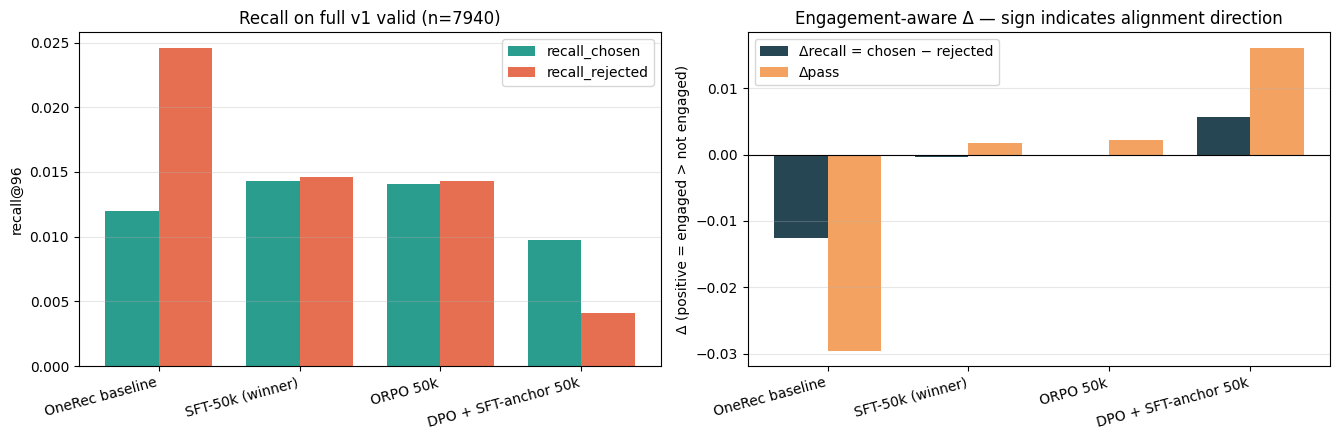

In [16]:
# Bar plot: recall on chosen vs rejected, all four arms.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

arms = list(ARMS.keys())
labels = [display_labels[a] for a in arms]
chosen_vals   = [eval_results[a]["recall_chosen"]   for a in arms]
rejected_vals = [eval_results[a]["recall_rejected"] for a in arms]

x = np.arange(len(arms)); w = 0.38
axes[0].bar(x - w/2, chosen_vals,   w, label="recall_chosen",   color="#2a9d8f")
axes[0].bar(x + w/2, rejected_vals, w, label="recall_rejected", color="#e76f51")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha="right")
axes[0].set_ylabel("recall@96")
axes[0].set_title("Recall on full v1 valid (n=7940)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Δrecall and Δpass, both engagement-aware metrics.
delta_recall = [eval_results[a]["delta_recall"] for a in arms]
delta_pass   = [eval_results[a]["delta_pass"]   for a in arms]
axes[1].bar(x - w/2, delta_recall, w, label="Δrecall = chosen − rejected", color="#264653")
axes[1].bar(x + w/2, delta_pass,   w, label="Δpass",                       color="#f4a261")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha="right")
axes[1].set_ylabel("Δ (positive = engaged > not engaged)")
axes[1].set_title("Engagement-aware Δ — sign indicates alignment direction")
axes[1].legend(loc="upper left")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


**The two plots tell complementary stories**:

- *Left*: SFT-50k and ORPO 50k both lift chosen recall above baseline (small but real). DPO+anchor's chosen recall **drops** to below baseline.
- *Right*: All three trained arms flip Δ sign vs baseline's strongly negative reading. DPO+anchor wins on Δ but only by crashing both sides asymmetrically — see Section 7.

## 7. Why DPO + SFT-anchor crashed chosen recall

The contrastive arm we originally proposed is the only arm whose chosen recall went **below baseline**. Mechanically:

```
gradient share ≈ 81% DPO contrastive  +  19% SFT anchor   (post-warmup, with sft_weight=0.15 raw)
```

The 81% DPO contrastive force has two basins that minimize `softplus(−margin)`:

1. **Push chosen up + push rejected down** (intended)
2. **Push both down asymmetrically — rejected harder than chosen** (cheaper)

Without enough SFT-anchor force pulling chosen up, basin 2 wins. The "implicit KL via reference baseline" that DPO papers cite is a *direction* constraint on `(chosen − rejected)`, **not** an absolute floor on chosen — chosen can drift below ref as long as rejected drifts faster.

A small numerical demonstration: set up a 2-D loss landscape with `c, r` as the trained log-probs (relative to a reference). Plot the contrastive loss `softplus(−β·(c − r))` as a contour, then overlay the gradient field. Both basins are visible.

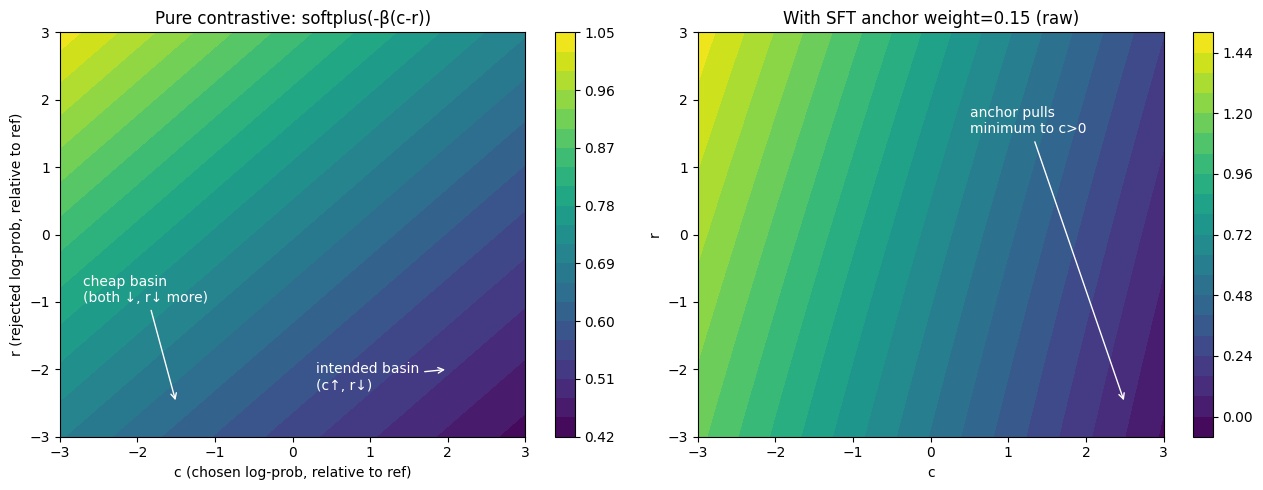

Left  — pure DPO contrastive: any direction with c−r increasing is equally good.
        Both 'push c up' (top-right) and 'push r way down' (bottom-left) are minima.
Right — with sft_weight=0.15 anchor: minimum tilts toward higher c, but the descent
        path still passes through the 'lower r faster than c' basin (visible as the
        gradient steering from origin toward bottom-right before climbing back up).

In the actual 50k run, this is exactly what happened: chosen drifted from
0.0143 → 0.0098 (−31%) while rejected dropped from 0.0146 → 0.0041 (−72%).
The 0.15 anchor was strong enough to prevent total collapse but too weak to
keep chosen above baseline.


In [17]:
# 2-D landscape: trained log-probs (c, r) relative to ref. β=0.1.
beta = 0.1
c_grid, r_grid = np.meshgrid(np.linspace(-3, 3, 80), np.linspace(-3, 3, 80))
margin = beta * (c_grid - r_grid)
L_dpo = np.log1p(np.exp(-margin))   # softplus(-margin)

# SFT anchor pulls toward higher c with weight sft_weight (small in our setup).
sft_weight = 0.15
L_sft = -c_grid                                   # purely linear in c
L_total = L_dpo + sft_weight * L_sft

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pure DPO contrastive — equal cost along the diagonal c−r=const.
cs0 = axes[0].contourf(c_grid, r_grid, L_dpo, levels=20, cmap="viridis")
axes[0].set_xlabel("c (chosen log-prob, relative to ref)")
axes[0].set_ylabel("r (rejected log-prob, relative to ref)")
axes[0].set_title("Pure contrastive: softplus(-β(c-r))")
axes[0].annotate("intended basin\n(c↑, r↓)", xy=(2.0, -2.0), xytext=(0.3, -2.3),
                 arrowprops=dict(arrowstyle="->", color="white"), color="white", fontsize=10)
axes[0].annotate("cheap basin\n(both ↓, r↓ more)", xy=(-1.5, -2.5), xytext=(-2.7, -1.0),
                 arrowprops=dict(arrowstyle="->", color="white"), color="white", fontsize=10)
plt.colorbar(cs0, ax=axes[0])

# Right: with weak SFT anchor — basin shifts but cheap basin still reachable.
cs1 = axes[1].contourf(c_grid, r_grid, L_total, levels=20, cmap="viridis")
axes[1].set_xlabel("c")
axes[1].set_ylabel("r")
axes[1].set_title(f"With SFT anchor weight={sft_weight} (raw)")
axes[1].annotate("anchor pulls\nminimum to c>0",
                 xy=(2.5, -2.5), xytext=(0.5, 1.5),
                 arrowprops=dict(arrowstyle="->", color="white"), color="white", fontsize=10)
plt.colorbar(cs1, ax=axes[1])

plt.tight_layout()
plt.show()

print("Left  — pure DPO contrastive: any direction with c−r increasing is equally good.")
print("        Both 'push c up' (top-right) and 'push r way down' (bottom-left) are minima.")
print("Right — with sft_weight=0.15 anchor: minimum tilts toward higher c, but the descent")
print("        path still passes through the 'lower r faster than c' basin (visible as the")
print("        gradient steering from origin toward bottom-right before climbing back up).")
print()
print("In the actual 50k run, this is exactly what happened: chosen drifted from")
print("0.0143 → 0.0098 (−31%) while rejected dropped from 0.0146 → 0.0041 (−72%).")
print("The 0.15 anchor was strong enough to prevent total collapse but too weak to")
print("keep chosen above baseline.")


## 8. Why ORPO ≈ SFT — zero-sum redistribution geometry

This is the project's deepest finding. ORPO's objective is fundamentally different from SFT — it has an **explicit** log-odds-ratio term that should reward separating chosen from rejected. Yet on this task ORPO ties with SFT to within noise.

The mechanism: when chosen and rejected items share a narrow categorical output space, **SFT's implicit zero-sum redistribution already does what the contrastive term tries to do**. Three structural conditions stack up:

1. **Narrow per-position vocabulary K = 8,192** (vs ~50k–150k for standard LLMs — 6–18× smaller). Pushing P(chosen_token) up by Δ drains Δ from the remaining K−1 entries — proportional to current mass.
2. **Chosen and rejected share user context.** Both come from the same session, so they live in the *same high-prob region* of the codebook. Rejected is the "nearest neighbor" of chosen.
3. **LoRA r=16 + 50k pairs hits a capacity ceiling.** Both arms saturate per-token chosen log P at ≈ −4.795 nats; lr/lora_r sweeps confirm data is the binding constraint.

**Numerical evidence from our trained models** — the headline result table in Section 6 already shows the prediction in action: SFT-50k (zero rejected supervision) drops `recall_rejected` from baseline 0.0246 → 0.0146 *purely as a side effect* of pushing chosen up. ORPO 50k (with an explicit rejected-suppression term) lands at 0.0143 — within 0.0003 of SFT, well inside the noise floor (paired SE ≈ 0.0013). The OR term has nothing additive to do because SFT's implicit zero-sum has already drained the high-prob neighborhood where rejected lives.

**The deeper takeaway** — this generalizes beyond our project:

> Whenever chosen and rejected share a narrow categorical output space, contrastive alignment objectives' marginal gains over plain SFT are absorbed into SFT's implicit zero-sum redistribution.

This applies to most generative recommenders (small token vocabularies, chosen/rejected from the same user context, low-rank fine-tunes). For these tasks, **plain SFT on the chosen branch suffices** — the contrastive machinery is largely redundant. ORPO's published wins on Mistral-on-UltraFeedback are exactly the *opposite* regime (large vocab, different prompts for y₊ vs y₋), where zero-sum doesn't bind.

## 9. Conclusion

### Research question — answered

> *Can user behavior signals directly replace the Reward Model when constructing preference pairs for offline alignment of a generative recommender?*

**Yes.** The simplest possible recipe — **SFT on the chosen branch, no contrastive term, no reference model, no group normalization** — lifts engagement-aware `recall_chosen` from baseline 0.0120 to 0.0143 (+19%, p≈0.005) and flips Δrecall sign from baseline's strongly biased −0.0126 to ≈ 0. No Reward Model required.

### Three concrete findings

1. **SFT-only on the chosen branch is sufficient** for the project's core claim. The original DPO+SFT+group-normalized contrastive arm we proposed *is the most complex arm we built* and underperforms — it is documented in Section 7 as a failure mode rather than a recommended method.

2. **ORPO ties with SFT** within noise (Section 6, 8) despite a fundamentally different objective. The structural reason is task-shaped, not method-shaped: small vocab + shared context + capacity-limited fine-tune compresses contrastive marginal gain to zero. **This generalizes to any narrow-vocabulary categorical alignment task.**

3. **Contrastive collapse is the dominant failure mode** in this regime. Five contrastive variants in our full 14-step ablation (see [`archive/EXPERIMENTS.md`](../archive/EXPERIMENTS.md)) failed in the same way — chosen drifts down or stays flat while rejected drops faster, producing a positive Δ that masks an absolute regression. Anchor-weight calibration is the single most important hyperparameter for any contrastive arm in this regime; our `sft_weight=0.15 raw` was too weak.

### What the headline number actually means

`SFT-50k Δrecall ≈ 0` is **not** a positive Δ. The honest reading: the OneRec base model is *anti-aligned* (rejected recall is 2× chosen recall), and 50k pairs of behavior-signal SFT **debiases** the model. It does not (yet) make it positively prefer engaged items, but the strongly anti-aligned baseline is removed. Δpass = +0.0018 / +0.0021 (SFT / ORPO) is consistent with "model is now neutral or weakly preference-aligned."

Future scale-up (200k+ pairs) would test whether this trajectory continues toward strong positive alignment.

### Repository pointers

- [`README.md`](../README.md) — project overview with the four-arm headline table
- [`archive/EXPERIMENTS.md`](../archive/EXPERIMENTS.md) — 14-step research journey, every dead end documented
- [`train/`](../train/) — all trainers and the engagement-aware evaluator
- [`scripts/`](../scripts/) — every launcher used in the final ablation
- [`evaluation_results/`](../evaluation_results/) — cached headline JSONs (this notebook's source of truth)
